In [1]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics
import scripts.algorithms

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)
importlib.reload(scripts.algorithms)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
name = "adult"
namex = "Adult"

d = 14


###knn
graphs = np.load("../graphs/"+name+"_knn_random.npy", allow_pickle=True)
###threshold
graphsz = np.load("../graphs/"+name+"_thresh_random.npy", allow_pickle=True)


# Standard model results

## Nearest neighbor

In [3]:
graphsinfor = []
for iz in range(len(graphs)):
    
    avg_left_deg, avg_left_pos_deg, avg_left_neg_deg, avg_right_deg, \
    avg_overlap,  avg_pos_overlap, avg_neg_overlap, only_pos, only_neg, \
    empty_adj, unipos  = scripts.analytics.getconnectivity_info(graphs[iz]["edges"], graphs[iz]["labels"])

    graphsinfor.append({
        "Dataset (d)": namex+" ("+ str(d) + ")",
        "kmax": graphs[iz]["k_max"], 
        "n": graphs[iz]['n'],
        "m": graphs[iz]['m'],
        "#+ves": len({t for t, l in graphs[iz]['labels'].items() if l == 1}),
        "#-ves": len({t for t, l in graphs[iz]['labels'].items() if l == -1}), 
        "avg LHSd": round(avg_left_deg,2), 
        "avg LHS+d": round(avg_left_pos_deg,2), 
        "avg LHS-d": round(avg_left_neg_deg,2),   
        "avg RHSd": round(avg_right_deg,2),          
        "avg overlap": round(avg_overlap,2), 
        "avg overlap+": round(avg_pos_overlap,2), 
        "avg overlap-": round(avg_neg_overlap,2), 
        "only+Ns": only_pos,
        "only-Ns": only_neg,
        "emptyNs": empty_adj,
        "uni+": unipos,
        "graphID": iz
    })

randomgraphsinfo = pd.DataFrame(graphsinfor)   
randomgraphsinfo



,Dataset (d),kmax,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Adult (14),1,328,46,10,36,1.0,0.21,0.79,7.13,0.03,0.01,0.03,70,258,0,0,0
1,Adult (14),2,328,49,12,37,2.0,0.48,1.52,13.39,0.11,0.03,0.08,15,184,0,0,1
2,Adult (14),3,328,49,12,37,3.0,0.78,2.22,20.08,0.27,0.08,0.19,4,121,0,0,2
3,Adult (14),4,328,49,12,37,4.0,1.08,2.92,26.78,0.49,0.17,0.31,2,86,0,0,3
4,Adult (14),5,328,49,12,37,5.0,1.41,3.59,33.47,0.76,0.30,0.46,1,61,0,0,4
5,Adult (14),6,328,49,12,37,6.0,1.73,4.27,40.16,1.11,0.45,0.66,0,44,0,0,5
6,Adult (14),7,328,49,12,37,7.0,2.01,4.99,46.86,1.50,0.60,0.90,0,33,0,0,6
7,Adult (14),8,328,49,12,37,8.0,2.35,5.65,53.55,1.96,0.79,1.17,0,19,0,0,7
8,Adult (14),9,328,49,12,37,9.0,2.69,6.31,60.24,2.48,1.01,1.47,0,12,0,0,8
9,Adult (14),10,328,49,12,37,10.0,2.96,7.04,66.94,3.04,1.21,1.83,0,10,0,0,9


In [4]:
print(scripts.analytics.df_to_latex_preserve(randomgraphsinfo))

\begin{tabular}{llllllllllllllllllllllllll}
Dataset & (d) & kmax & n & m & #+ves & #-ves & avg & LHSd & avg & LHS+d & avg & LHS-d & avg & RHSd & avg & overlap & avg & overlap+ & avg & overlap- & only+Ns & only-Ns & emptyNs & uni+ & graphID \\
\hline
Adult & (14) & 1 & 328 & 46 & 10 & 36 & 1.0 & 0.21 & 0.79 & 7.13 & 0.03 & 0.01 & 0.03 & 70 & 258 & 0 & 0 & 0 \\
Adult & (14) & 2 & 328 & 49 & 12 & 37 & 2.0 & 0.48 & 1.52 & 13.39 & 0.11 & 0.03 & 0.08 & 15 & 184 & 0 & 0 & 1 \\
Adult & (14) & 3 & 328 & 49 & 12 & 37 & 3.0 & 0.78 & 2.22 & 20.08 & 0.27 & 0.08 & 0.19 & 4 & 121 & 0 & 0 & 2 \\
Adult & (14) & 4 & 328 & 49 & 12 & 37 & 4.0 & 1.08 & 2.92 & 26.78 & 0.49 & 0.17 & 0.31 & 2 & 86 & 0 & 0 & 3 \\
Adult & (14) & 5 & 328 & 49 & 12 & 37 & 5.0 & 1.41 & 3.59 & 33.47 & 0.76 & 0.30 & 0.46 & 1 & 61 & 0 & 0 & 4 \\
Adult & (14) & 6 & 328 & 49 & 12 & 37 & 6.0 & 1.73 & 4.27 & 40.16 & 1.11 & 0.45 & 0.66 & 0 & 44 & 0 & 0 & 5 \\
Adult & (14) & 7 & 328 & 49 & 12 & 37 & 7.0 & 2.01 & 4.99 & 46.86 & 1.50 & 0.60 

## Thresholding

In [5]:
graphsinforx = []
for ix in range(len(graphsz)):
    
    avg_left_degx, avg_left_pos_degx, avg_left_neg_degx, avg_right_degx, \
    avg_overlapx, avg_pos_overlapx, avg_neg_overlapx, only_posx, only_negx, \
    empty_adjx, uniposx  = scripts.analytics.getconnectivity_info(graphsz[ix]["edges"], graphsz[ix]["labels"])
        
    graphsinforx.append({
        "Dataset (d)":namex+" ("+ str(d) + ")",
        "r": graphsz[ix]["threshold"], 
        "n": graphsz[ix]['n'],
        "m": graphsz[ix]['m'],
        "#+ves": len({t for t, l in graphsz[ix]['labels'].items() if l == 1}),
        "#-ves": len({t for t, l in graphsz[ix]['labels'].items() if l == -1}), 
        "avg LHSd": round(avg_left_degx,2),  
        "avg LHS+d": round(avg_left_pos_degx,2),  
        "avg LHS-d": round(avg_left_neg_degx,2),   
        "avg RHSd": round(avg_right_degx,2),          
        "avg overlap": round(avg_overlapx,2), 
        "avg overlap+": round(avg_pos_overlapx,2), 
        "avg overlap-": round(avg_neg_overlapx,2), 
        "only+Ns": only_posx,
        "only-Ns": only_negx,
        "emptyNs": empty_adjx,
        "uni+": uniposx,
        "graphID": ix
    })

randomgraphsinfox = pd.DataFrame(graphsinforx)   
randomgraphsinfox


,Dataset (d),r,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Adult (14),4.0,328,48,12,36,12.70,3.72,8.98,86.75,4.56,1.53,3.04,6,51,35,0,0
1,Adult (14),4.5,328,49,12,37,19.55,5.26,14.28,130.84,9.62,2.79,6.84,2,33,21,0,1
2,Adult (14),5.0,328,49,12,37,27.00,6.87,20.13,180.76,17.00,4.46,12.54,2,20,9,0,2
3,Adult (14),5.5,328,49,12,37,33.47,8.34,25.12,224.02,24.90,6.20,18.70,0,9,6,0,3
4,Adult (14),6.0,328,49,12,37,38.95,9.61,29.34,260.73,32.54,7.91,24.63,0,6,2,0,4
5,Adult (14),6.5,328,49,12,37,42.83,10.59,32.24,286.69,38.46,9.44,29.02,1,4,0,0,5
6,Adult (14),7.0,328,49,12,37,45.70,11.29,34.41,305.90,43.12,10.65,32.47,0,2,0,0,6
7,Adult (14),7.5,328,49,12,37,47.35,11.70,35.66,316.96,45.95,11.40,34.54,0,0,0,0,7
8,Adult (14),8.0,328,49,12,37,48.26,11.89,36.37,323.02,47.58,11.78,35.80,0,0,0,2,8
9,Adult (14),8.5,328,49,12,37,48.70,11.96,36.74,325.98,48.41,11.92,36.49,0,0,0,6,9


In [6]:
print(scripts.analytics.df_to_latex_preserve(randomgraphsinfox))

\begin{tabular}{llllllllllllllllllllllllll}
Dataset & (d) & r & n & m & #+ves & #-ves & avg & LHSd & avg & LHS+d & avg & LHS-d & avg & RHSd & avg & overlap & avg & overlap+ & avg & overlap- & only+Ns & only-Ns & emptyNs & uni+ & graphID \\
\hline
Adult & (14) & 4.0 & 328 & 48 & 12 & 36 & 12.70 & 3.72 & 8.98 & 86.75 & 4.56 & 1.53 & 3.04 & 6 & 51 & 35 & 0 & 0 \\
Adult & (14) & 4.5 & 328 & 49 & 12 & 37 & 19.55 & 5.26 & 14.28 & 130.84 & 9.62 & 2.79 & 6.84 & 2 & 33 & 21 & 0 & 1 \\
Adult & (14) & 5.0 & 328 & 49 & 12 & 37 & 27.00 & 6.87 & 20.13 & 180.76 & 17.00 & 4.46 & 12.54 & 2 & 20 & 9 & 0 & 2 \\
Adult & (14) & 5.5 & 328 & 49 & 12 & 37 & 33.47 & 8.34 & 25.12 & 224.02 & 24.90 & 6.20 & 18.70 & 0 & 9 & 6 & 0 & 3 \\
Adult & (14) & 6.0 & 328 & 49 & 12 & 37 & 38.95 & 9.61 & 29.34 & 260.73 & 32.54 & 7.91 & 24.63 & 0 & 6 & 2 & 0 & 4 \\
Adult & (14) & 6.5 & 328 & 49 & 12 & 37 & 42.83 & 10.59 & 32.24 & 286.69 & 38.46 & 9.44 & 29.02 & 1 & 4 & 0 & 0 & 5 \\
Adult & (14) & 7.0 & 328 & 49 & 12 & 37 & 45.

# Load the algorithmic results

In [7]:
greedy_bruteforce_algosdf = pd.read_csv("./sm_results/"+name+"_knn_greedy_rdm_bruteforce.csv")
all_bruteforce = pd.read_csv("./sm_results/"+name+"_knn_allbruteforce.csv")

greedy_bruteforce_algosdfz = pd.read_csv("./sm_results/"+name+"_thresh_greedy_rdm_bruteforce.csv")
all_bruteforcez = pd.read_csv("./sm_results/"+name+"_thresh_allbruteforce.csv")


In [8]:
summary_df = pd.read_csv("./sm_results/"+name+"_knn_summary.csv")
greedyalgo_df = pd.read_csv("./sm_results/"+name+"_knn_greedyheuristic.csv")
randomalgo_df = pd.read_csv("./sm_results/"+name+"_knn_randomheuristic.csv")


summary_dfx = pd.read_csv("./sm_results/"+name+"_thresh_summary.csv")
greedyalgo_dfx = pd.read_csv("./sm_results/"+name+"_thresh_greedyheuristic.csv")
randomalgo_dfx = pd.read_csv("./sm_results/"+name+"_thresh_randomheuristic.csv")


# Compute social welfare given an empty set

## Nearest neighbor

In [9]:
results_knn = []

for lx in range(len(graphs)):

    r_edges_randomx  = graphs[lx]["edges"]
    r_labels_randomx = graphs[lx]["labels"]
    
    
    ###############
    Sx = set()
    cur_utility = scripts.algorithms.F_S(r_edges_randomx, r_labels_randomx, Sx)

    
    ###############
    for Kx in [1, 2, 3, 4, 5]:
        
        #######
        results_knn.append({
            "kmax": graphs[lx]["k_max"],
            "graphid": lx,
            "K": Kx,
            "F(So)": cur_utility


        })


mddfa = summary_df.merge(pd.DataFrame(results_knn), on=["kmax", "graphid", "K"], how="left")

mdf = mddfa.merge(greedy_bruteforce_algosdf[["kmax", "graphid", "K", "F(S*)"]], on=["kmax", "graphid", "K"], how="left")

pd.DataFrame(results_knn).tail()


,kmax,graphid,K,F(So)
45,10,9,1,97.0
46,10,9,2,97.0
47,10,9,3,97.0
48,10,9,4,97.0
49,10,9,5,97.0


## Thresholding

In [10]:
results_thresh = []

for lz in range(len(graphsz)):

    r_edges_randomz  = graphsz[lz]["edges"]
    r_labels_randomz = graphsz[lz]["labels"]
    
    
    ###############
    Sz = set()
    cur_utilityz = scripts.algorithms.F_S(r_edges_randomz, r_labels_randomz, Sz)

    
    ###############
    for Kz in [1, 2, 3, 4, 5]:
        
        #######
        results_thresh.append({
            "r": graphsz[lz]["threshold"],
            "graphid": lz,
            "K": Kz,
            "F(So)": cur_utilityz


        })

        
mddfaz = summary_dfx.merge(pd.DataFrame(results_thresh), on=["r", "graphid", "K"], how="left")

mdfz = mddfaz.merge(greedy_bruteforce_algosdfz[["r", "graphid", "K", "F(S*)"]], on=["r", "graphid", "K"], how="left")

pd.DataFrame(results_thresh).tail()


,r,graphid,K,F(So)
60,10.0,12,1,80.336735
61,10.0,12,2,80.336735
62,10.0,12,3,80.336735
63,10.0,12,4,80.336735
64,10.0,12,5,80.336735


# Standard model results plots

## Nearest neighbor

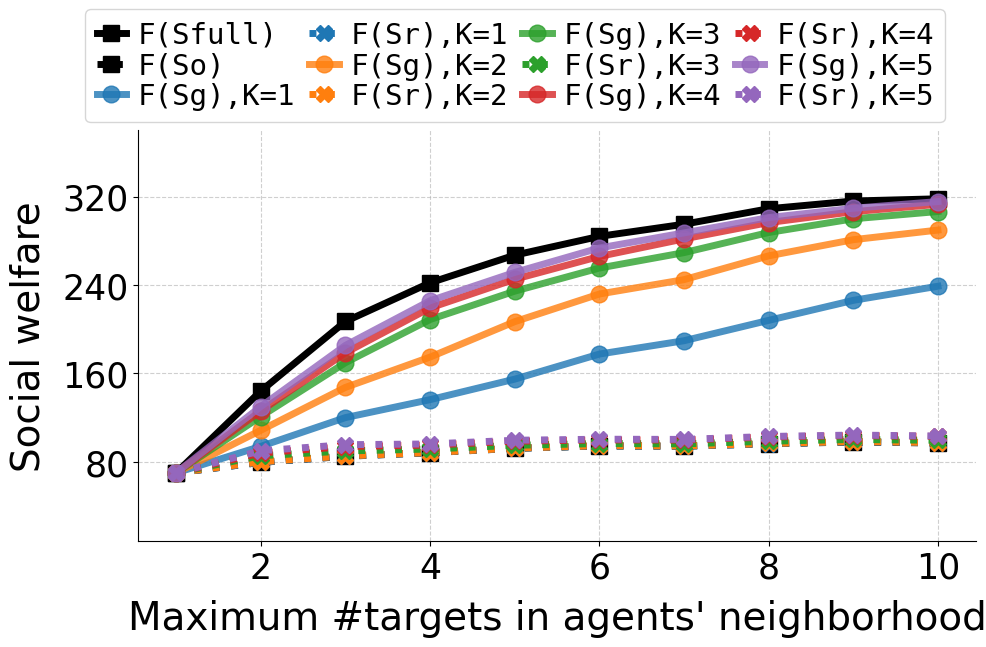

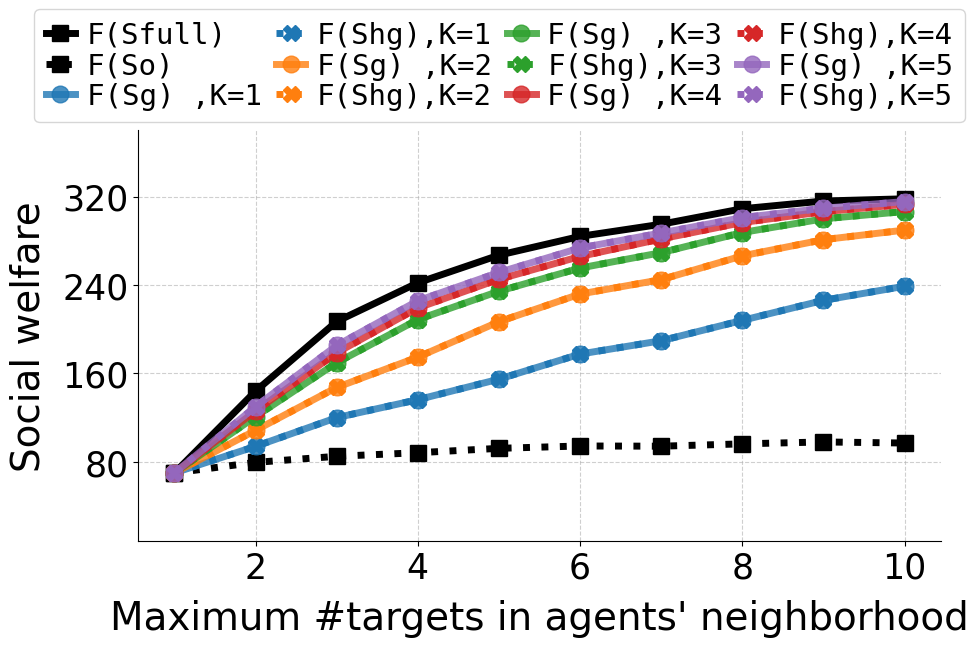

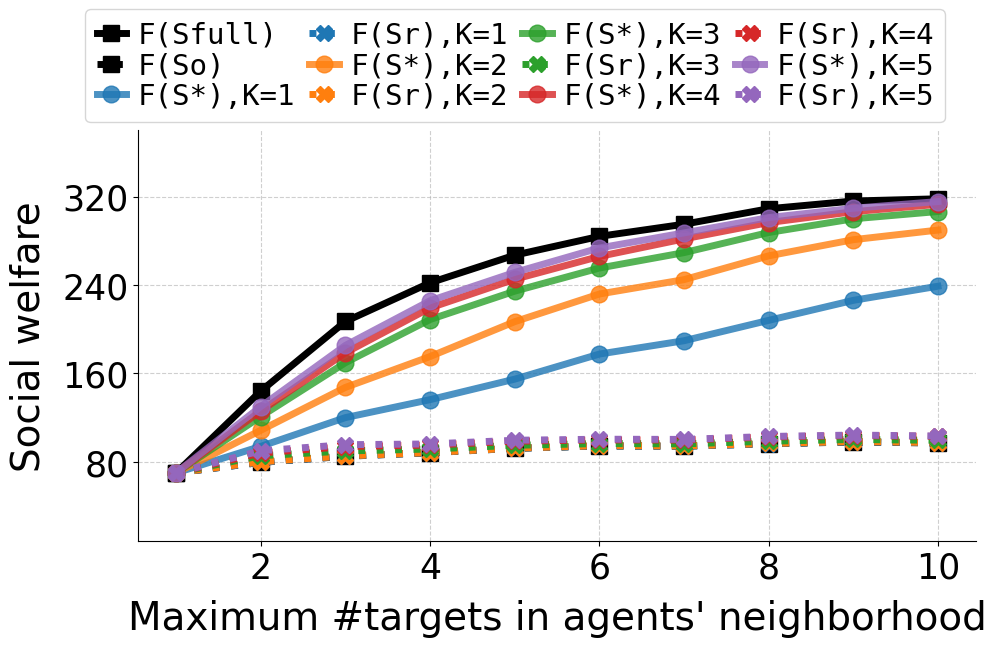

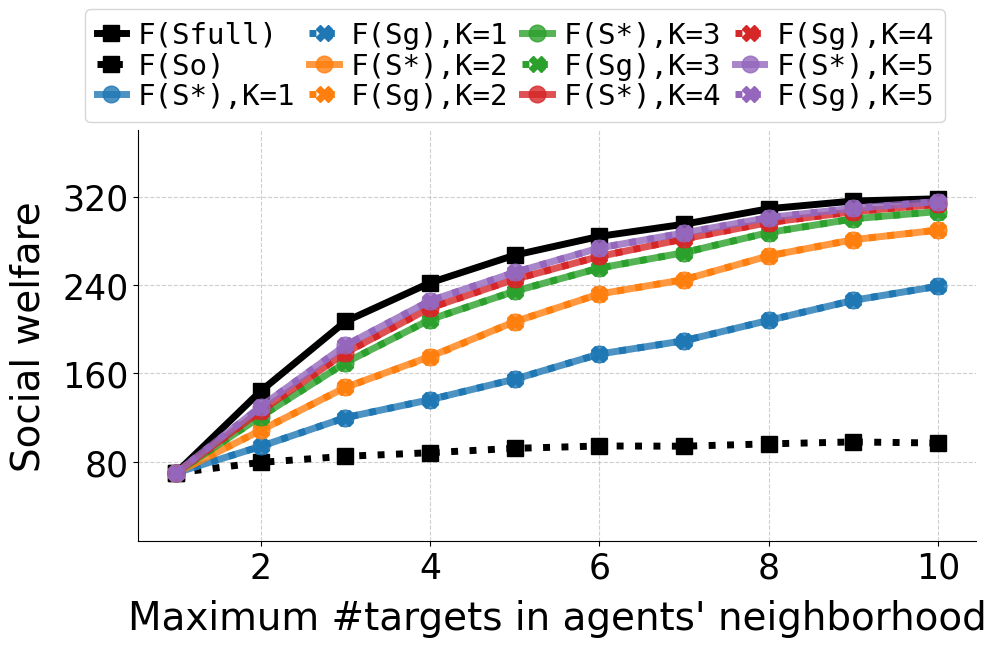

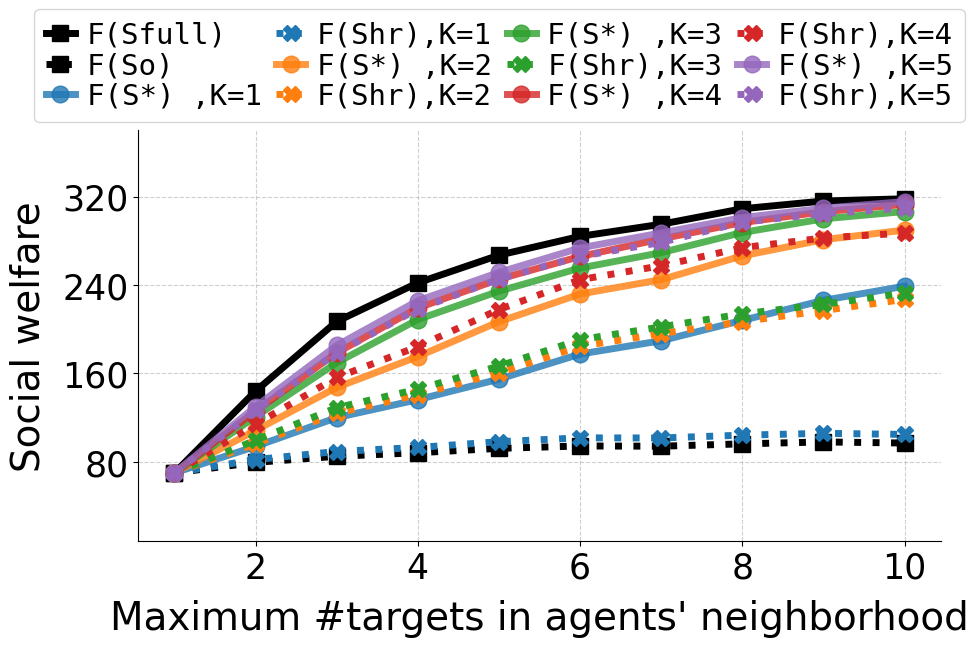

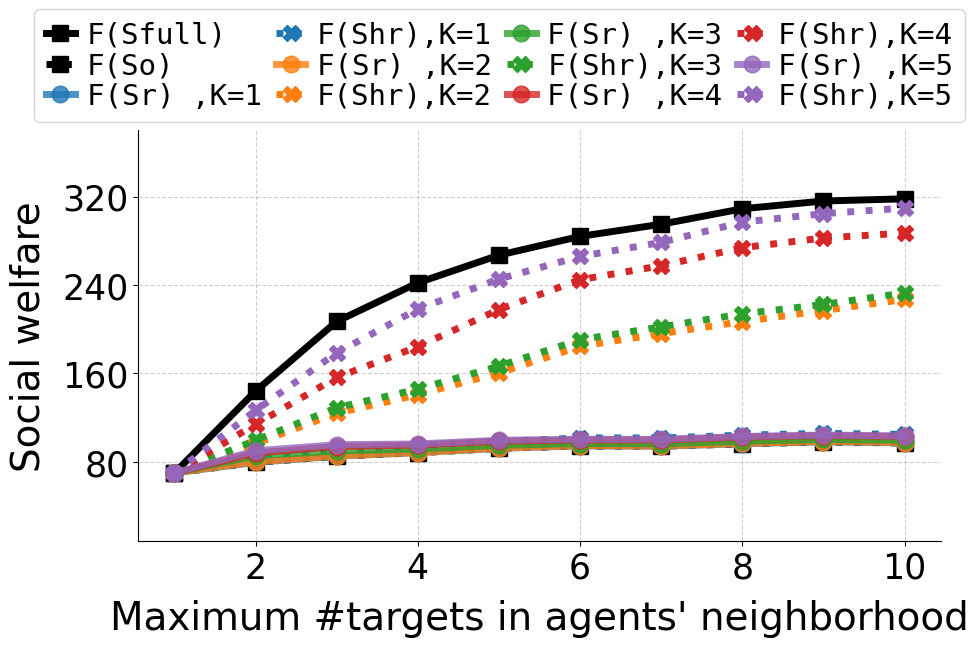

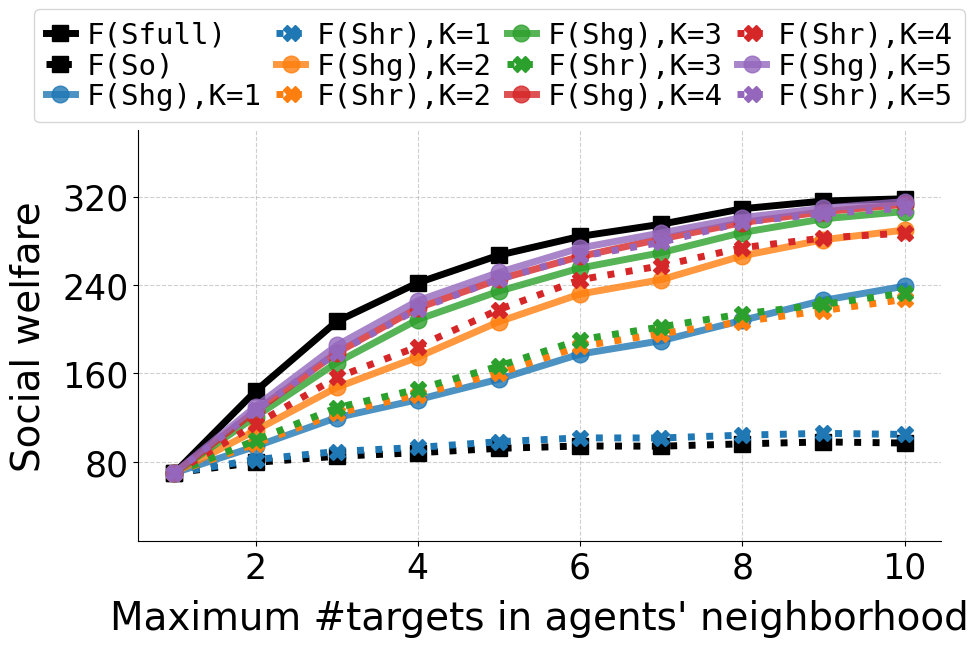

In [11]:
daz1 = mdf[["K", "F(Sg)", "F(Sr)", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz1, x_col="kmax", ycol1="F(Sg)", ycol2="F(Sr)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sg),", ycol2_name="F(Sr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sr_sg_knn.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz2 = mdf[["K", "F(Sg)", "F(Sg+ U Sg-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz2, x_col="kmax", ycol1="F(Sg)", ycol2="F(Sg+ U Sg-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sg) ,", ycol2_name="F(Shg),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",   
                                   save_as="./sm_results/figures/aplot_"+namex+"_sg_shg_knn.pdf",
                                   figsize=(10, 7), showfig=True)



############################
daz144 = mdf[["K", "F(Sg)", "F(Sr)", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz144, x_col="kmax", ycol1="F(S*)", ycol2="F(Sr)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*),", ycol2_name="F(Sr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_sr_knn.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz244 = mdf[["K", "F(Sg)", "F(Sg+ U Sg-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz244, x_col="kmax", ycol1="F(S*)", ycol2="F(Sg)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*),", ycol2_name="F(Sg),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_sg_knn.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz245 = mdf[["K", "F(Sg)", "F(Sr+ U Sr-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz245, x_col="kmax", ycol1="F(S*)", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*) ,", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_shr_knn.pdf",
                                   figsize=(10, 7), showfig=True)


    
###########################
daz3 = mdf[["K", "F(Sr)", "F(Sr+ U Sr-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]

scripts.analytics.sm_results_plot(daz3, x_col="kmax", ycol1="F(Sr)", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sr) ,", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sr_shr_knn.pdf",
                                   figsize=(10, 7), showfig=True)



###########################
daz4 = mdf[["K", "F(Sg+ U Sg-)*", "F(Sr+ U Sr-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]

scripts.analytics.sm_results_plot(daz4, x_col="kmax", ycol1="F(Sg+ U Sg-)*", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Shg),", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_shg_shr_knn.pdf",
                                   figsize=(10, 7), showfig=True)

    
    

## Thresholding

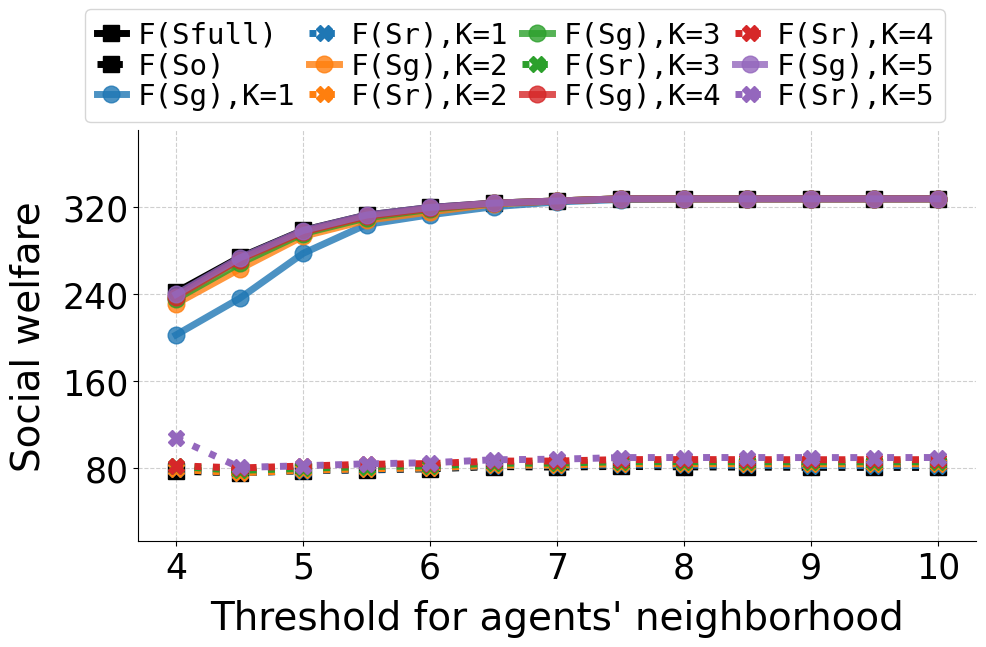

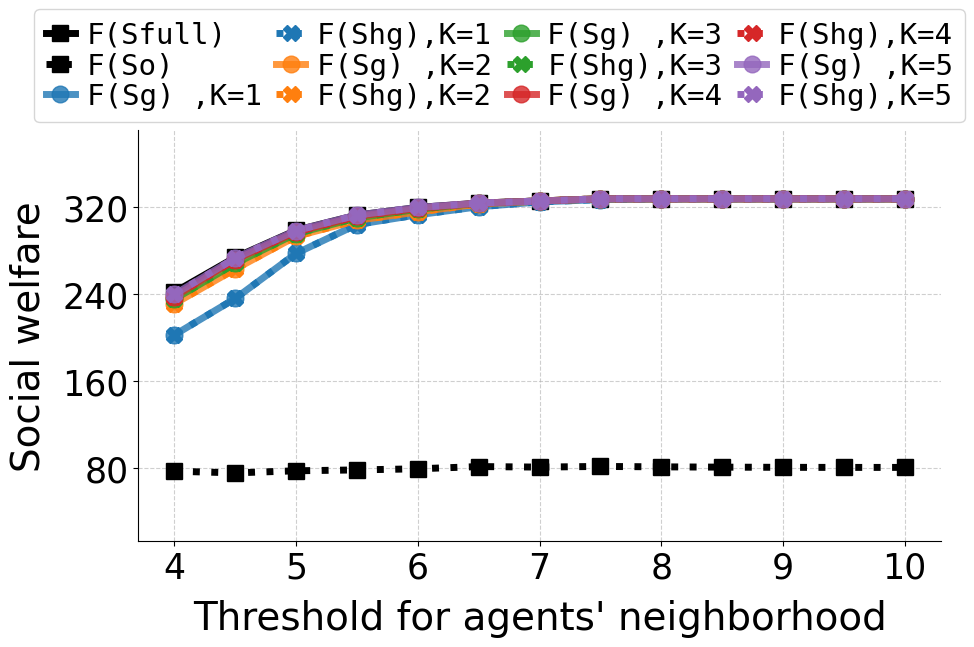

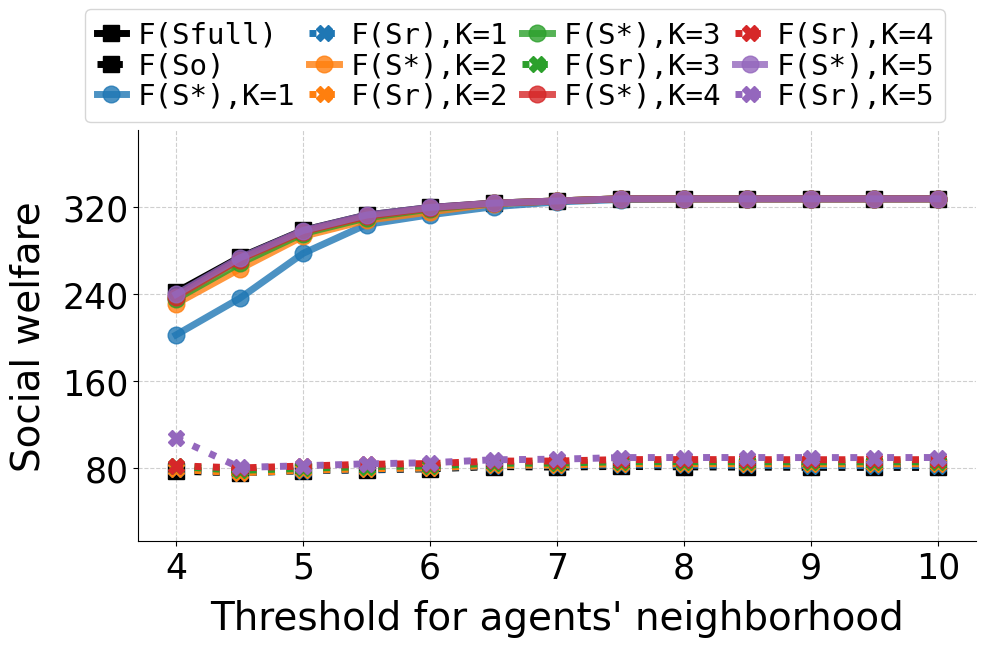

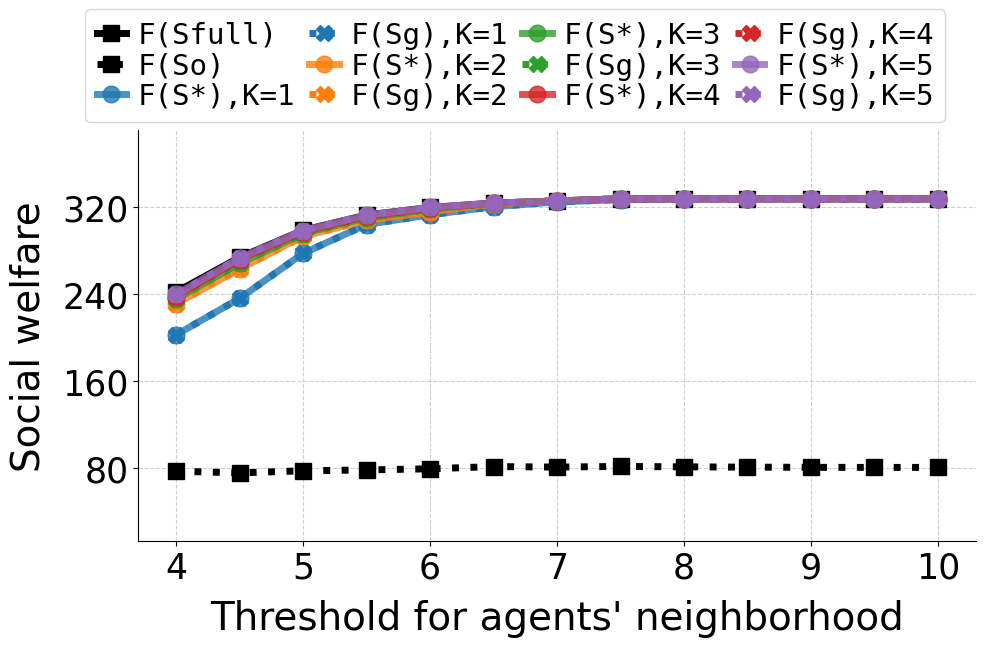

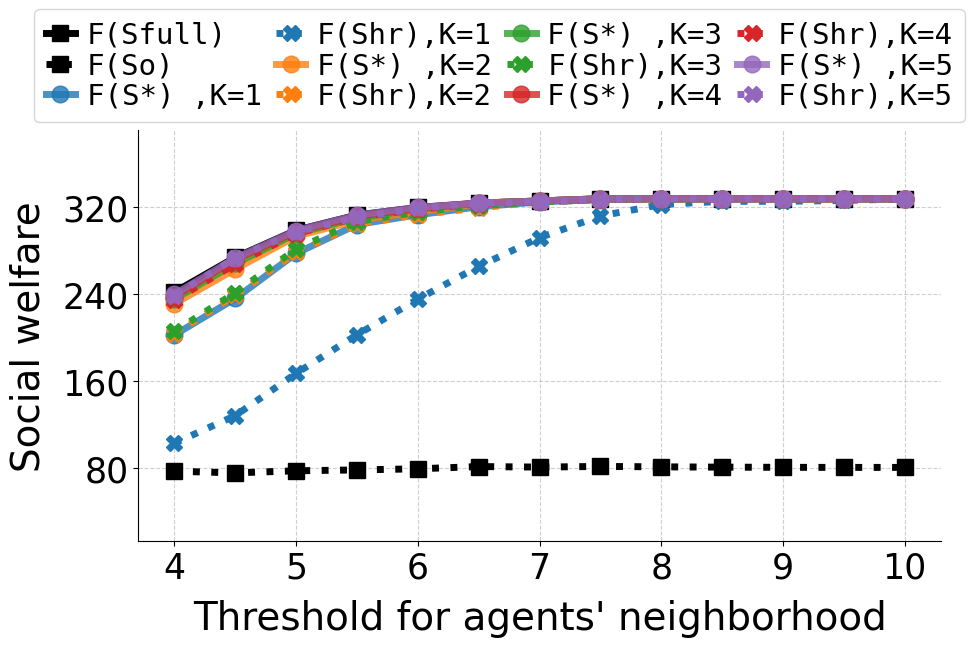

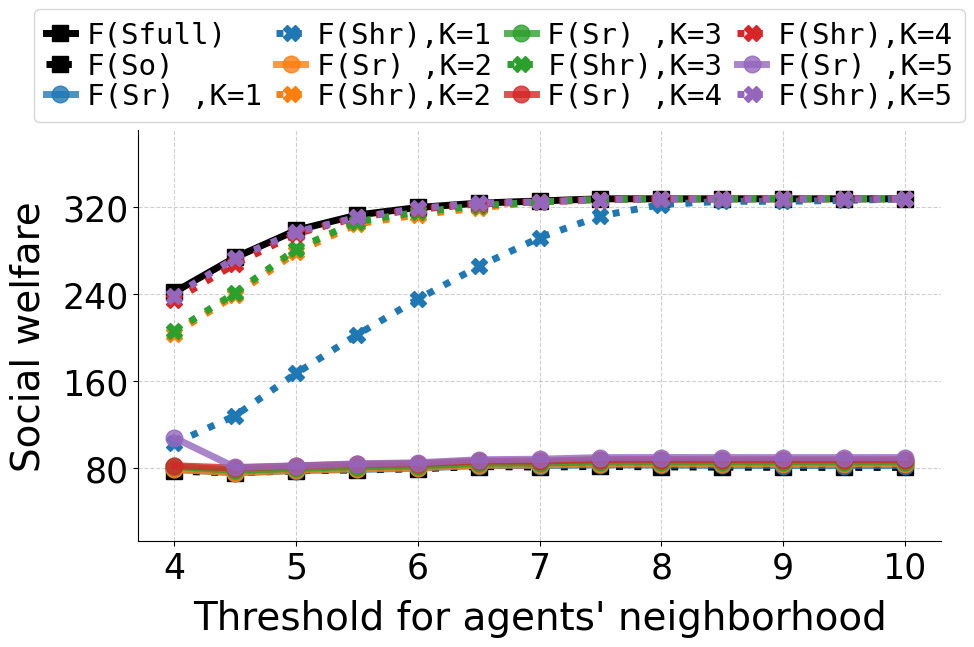

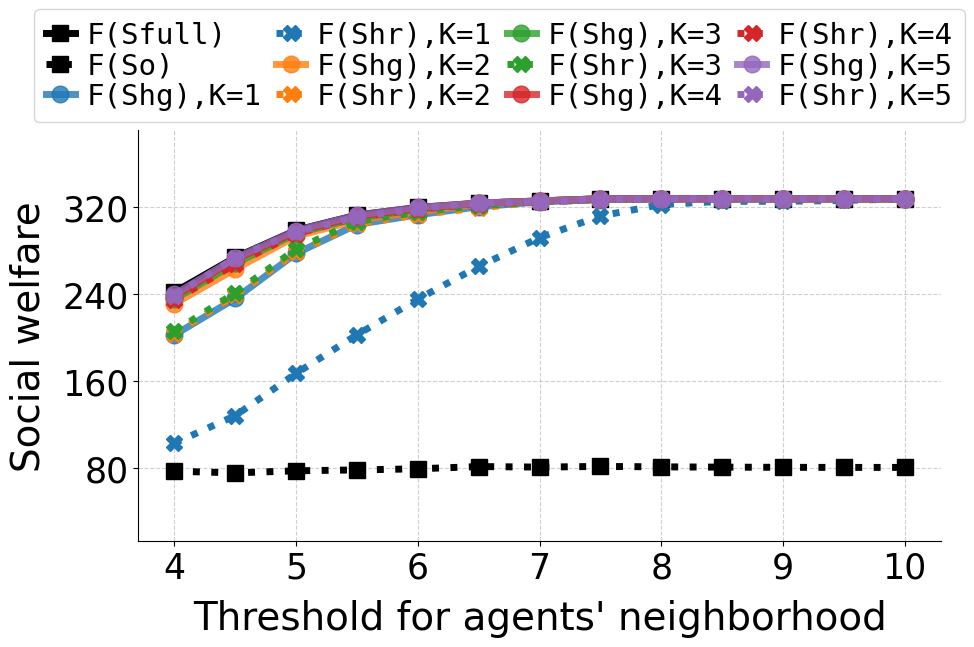

In [12]:
daz11 = mdfz[["K", "F(Sg)", "F(Sr)", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz11, x_col="r", ycol1="F(Sg)", ycol2="F(Sr)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sg),", ycol2_name="F(Sr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sr_sg_thresh.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz22 = mdfz[["K", "F(Sg)", "F(Sg+ U Sg-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz22, x_col="r", ycol1="F(Sg)", ycol2="F(Sg+ U Sg-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sg) ,", ycol2_name="F(Shg),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sg_shg_thresh.pdf",
                                   figsize=(10, 7), showfig=True)



############################
daz1144 = mdfz[["K", "F(Sg)", "F(Sr)", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz1144, x_col="r", ycol1="F(S*)", ycol2="F(Sr)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*),", ycol2_name="F(Sr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)",
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_sr_thresh.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz2244 = mdfz[["K", "F(Sg)", "F(Sg+ U Sg-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz2244, x_col="r", ycol1="F(S*)", ycol2="F(Sg)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*),", ycol2_name="F(Sg),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_sg_thresh.pdf",
                                   figsize=(10, 7), showfig=True)



############################
daz2245 = mdfz[["K", "F(Sg)", "F(Sr+ U Sr-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz2245, x_col="r", ycol1="F(S*)", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*) ,", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_shr_thresh.pdf",
                                   figsize=(10, 7), showfig=True)



###########################
daz33 = mdfz[["K", "F(Sr)", "F(Sr+ U Sr-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]

scripts.analytics.sm_results_plot(daz33, x_col="r", ycol1="F(Sr)", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sr) ,", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sr_shr_thresh.pdf",
                                   figsize=(10, 7), showfig=True)



###########################
daz44 = mdfz[["K", "F(Sg+ U Sg-)*", "F(Sr+ U Sr-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]

scripts.analytics.sm_results_plot(daz44, x_col="r", ycol1="F(Sg+ U Sg-)*", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Shg),", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_shg_shr_thresh.pdf",
                                   figsize=(10, 7), showfig=True)


  